In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [68]:
df = pd.read_csv('../csv-data/drinks.csv', encoding = 'UTF-8')
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF
...,...,...,...,...,...,...
188,Venezuela,333,100,3,7.7,SA
189,Vietnam,111,2,1,2.0,AS
190,Yemen,6,0,0,0.1,AS
191,Zambia,32,19,4,2.5,AF


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    object 
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
 5   continent                     170 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.2+ KB


In [5]:
df.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,193.000000,193.000000,193.000000
mean,106.160622,80.994819,49.450777,4.717098
std,101.143103,88.284312,79.697598,3.773298
min,0.000000,0.000000,0.000000,0.000000
25%,20.000000,4.000000,1.000000,1.300000
50%,76.000000,56.000000,8.000000,4.200000
75%,188.000000,128.000000,59.000000,7.200000
max,376.000000,438.000000,370.000000,14.400000


In [6]:
df['continent'].unique() # sql문에서 distinct과 동일

array(['AS', 'EU', 'AF', nan, 'SA', 'OC'], dtype=object)

In [7]:
df['continent'].value_counts()

continent
AF    53
EU    45
AS    44
OC    16
SA    12
Name: count, dtype: int64

In [8]:
df.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF


In [9]:
df.tail()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
188,Venezuela,333,100,3,7.7,SA
189,Vietnam,111,2,1,2.0,AS
190,Yemen,6,0,0,0.1,AS
191,Zambia,32,19,4,2.5,AF
192,Zimbabwe,64,18,4,4.7,AF


In [10]:
df[5:10]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
5,Antigua & Barbuda,102,128,45,4.9,NaN
6,Argentina,193,25,221,8.3,SA
7,Armenia,21,179,11,3.8,EU
8,Australia,261,72,212,10.4,OC
9,Austria,279,75,191,9.7,EU


In [11]:
df[df['country'] == 'South Korea']

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
138,South Korea,140,16,9,9.8,AS


In [12]:
df[df['continent'] == 'AS']

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0,0,0,0.0,AS
12,Bahrain,42,63,7,2.0,AS
13,Bangladesh,0,0,0,0.0,AS
19,Bhutan,23,0,0,0.4,AS
24,Brunei,31,2,1,0.6,AS
30,Cambodia,57,65,1,2.2,AS
36,China,79,192,8,5.0,AS
46,North Korea,0,0,0,0.0,AS
77,India,9,114,0,2.2,AS
78,Indonesia,5,1,0,0.1,AS


In [13]:
df[df['continent'] == 'AS'].count() # 행수

country                         44
beer_servings                   44
spirit_servings                 44
wine_servings                   44
total_litres_of_pure_alcohol    44
continent                       44
dtype: int64

In [14]:
df[df['continent'] == 'AF'].count()

country                         53
beer_servings                   53
spirit_servings                 53
wine_servings                   53
total_litres_of_pure_alcohol    53
continent                       53
dtype: int64

In [15]:
df.groupby(df['continent']).count()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
continent,,,,,
AF,53,53,53,53,53
AS,44,44,44,44,44
EU,45,45,45,45,45
OC,16,16,16,16,16
SA,12,12,12,12,12


In [16]:
# 컬럼간의 관계(상관관계)를 알아볼 수 있다.
# 맥주를 많이 마시는 나라는 와인도 많이 마실까? 안마실까?
# df[] 조건
# df[df[컬럼명] == '값'] 조건인데 컬럼명의 값을 가지고 검색함.
# df['컬럼명'] 컬럼 1개 선택
# df[['컬럼명', '컬럼명2']] 컬럼 여러개 선택할 때는 하나로 묶어주어야함.

In [17]:
df.columns

Index(['country', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')

In [18]:
df[['beer_servings', 'spirit_servings']].corr() # 상관관계를 알고 싶을 때

,beer_servings,spirit_servings
beer_servings,1.000000,0.458819
spirit_servings,0.458819,1.000000


In [19]:
heat_data = df[['wine_servings', 'spirit_servings']].corr()
heat_data

,wine_servings,spirit_servings
wine_servings,1.000000,0.194797
spirit_servings,0.194797,1.000000


In [20]:
# df.corr() # 각 컬럼간의 관계를 알고 싶으면 df.corr() : 피어슨 상관계수

In [21]:
# 상관도를 구하고 나서 수치보는 법
# 0.7~1 : 높은 상관관계
# 0.5~0.7 : 중간 상관관계
# 0.3~0.5 : 낮은 상관관계
# 0 ~ 0.3 : 아주 낮은 상관관계
# 상관계수가 +이면, 양의 상관관계
# 상관계수가 -이면, 음의 상관관계

In [22]:
# wine, beer
# spirit : 보드카
# total_litres_of_pure_alcohol : 총 알콜 소비량 

In [23]:
# corr = df.corr() #피어슨 상관계수
# corr

In [24]:
import seaborn as sns

In [25]:
cols = ['wine', 'spirit']

In [26]:
sns.set(font_scale=1.5)

<Axes: >

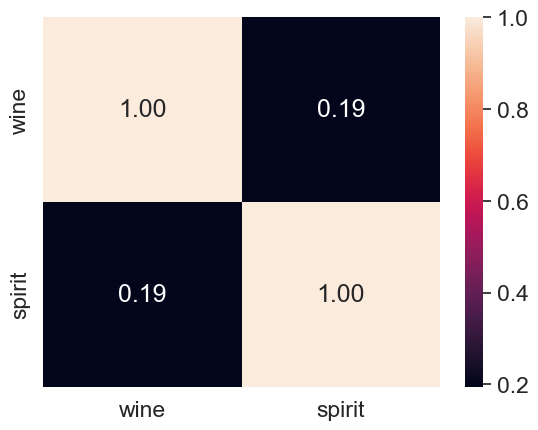

In [27]:
sns.heatmap(heat_data,
            cbar = True,
            annot = True,
            fmt = ".2f",
            xticklabels = cols,
            yticklabels = cols
           )

In [28]:
# 와인과 맥주간의 상관계수를 구해서 heat_data2에 넣어서 출력
# heat_data2의 타입을 출력
# cols2를 다시 만들어야함.(와인, 맥주)
# heatmap을 그려보세요.

In [29]:
df.columns

Index(['country', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')

In [30]:
heat_data2 = df[['wine_servings', 'beer_servings']].corr()
heat_data2

,wine_servings,beer_servings
wine_servings,1.000000,0.527172
beer_servings,0.527172,1.000000


In [31]:
type(heat_data2)

pandas.core.frame.DataFrame

In [32]:
cols2 = ['wine', 'beer']

<Axes: >

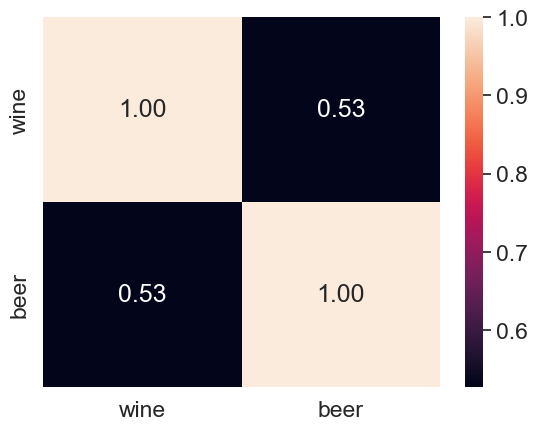

In [33]:
sns.heatmap(heat_data2,
            cbar = True,
            annot = True,
            fmt = ".2f",
            xticklabels = cols2,
            yticklabels = cols2
           )

In [34]:
# 와인과 맥주, 증류수 간의 상관계수를 구해서 heat_data0에 넣어서 출력
# heat_data0의 타입을 출력
# cols0을 다시 만들어야함.(와인, 맥주, 증류수)
# heatmap을 그려보세요.

In [35]:
df.columns

Index(['country', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')

In [36]:
heat_data0 = df[['wine_servings', 'beer_servings', 'spirit_servings']].corr()
heat_data0

,wine_servings,beer_servings,spirit_servings
wine_servings,1.000000,0.527172,0.194797
beer_servings,0.527172,1.000000,0.458819
spirit_servings,0.194797,0.458819,1.000000


In [37]:
cols0 = ['wine', 'beer', 'spirit']

<Axes: >

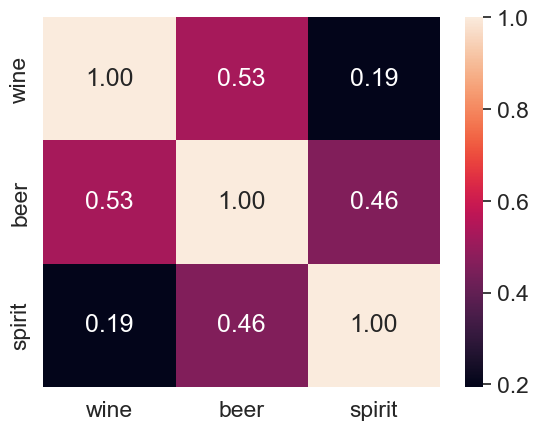

In [38]:
sns.heatmap(heat_data0,
            cbar = True,
            annot = True,
            fmt = ".2f",
            xticklabels = cols0,
            yticklabels = cols0
           )

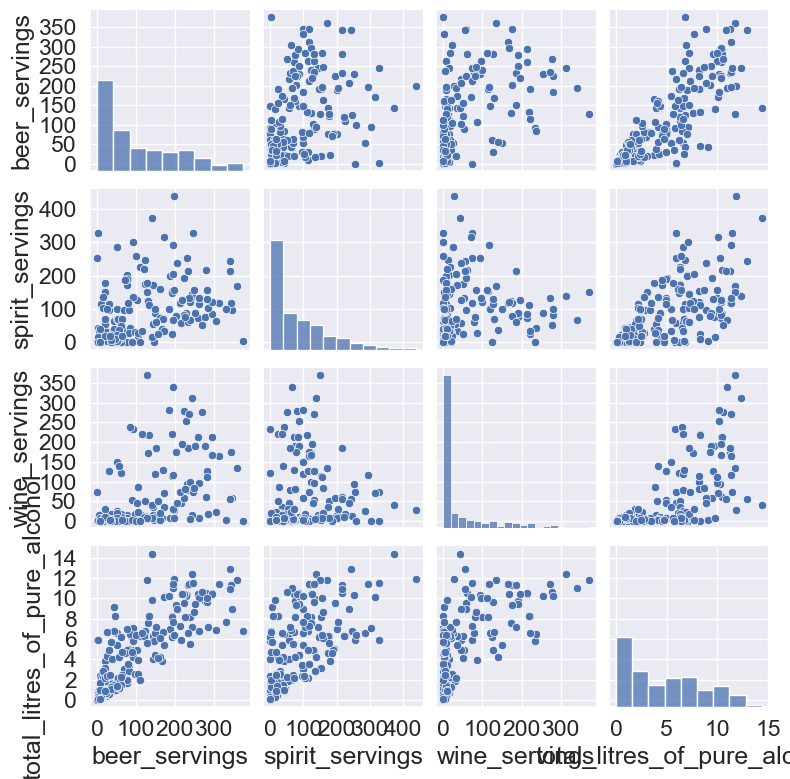

In [39]:
sns.pairplot(df, height=2)
sns.set(font_scale=0.5)
plt.show()

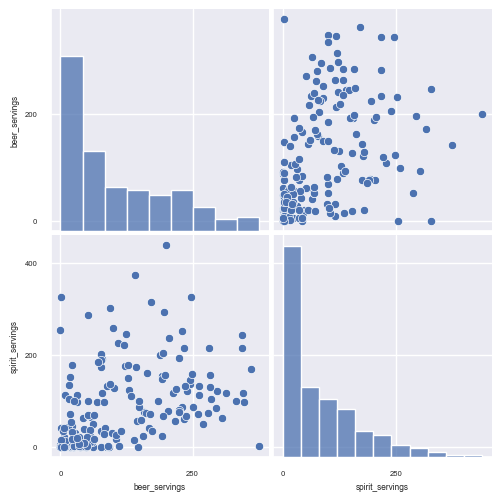

In [40]:
sns.pairplot(df[['beer_servings', 'spirit_servings']], height=2.5)
sns.set(font_scale=2.0)
plt.show()

In [41]:
##titanic data read! -> corr, heatmap, pairplot
df2 = pd.read_csv('../csv-data/titanic.csv')
df2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [42]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [43]:
df2.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [44]:
corr2 = df2[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone']].corr()
# corr2 = df2.select_dtypes(include=['number']).corr()
corr2

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


In [45]:
sns.set(font_scale=1.0)

In [46]:
# cols3 = ['survived','pclass','age','sibsp','parch','fare','adult_male','alone']

<Axes: >

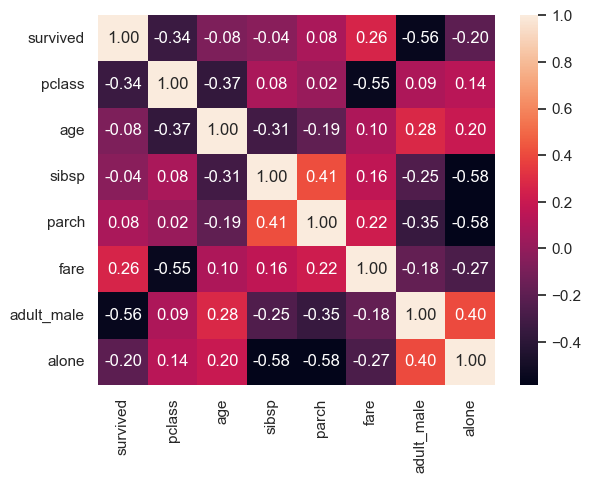

In [47]:
sns.heatmap(corr2.values,
            cbar = True,
            annot= True,
            fmt = '.2f',
            xticklabels=corr2.columns,
            yticklabels=corr2.columns
           )

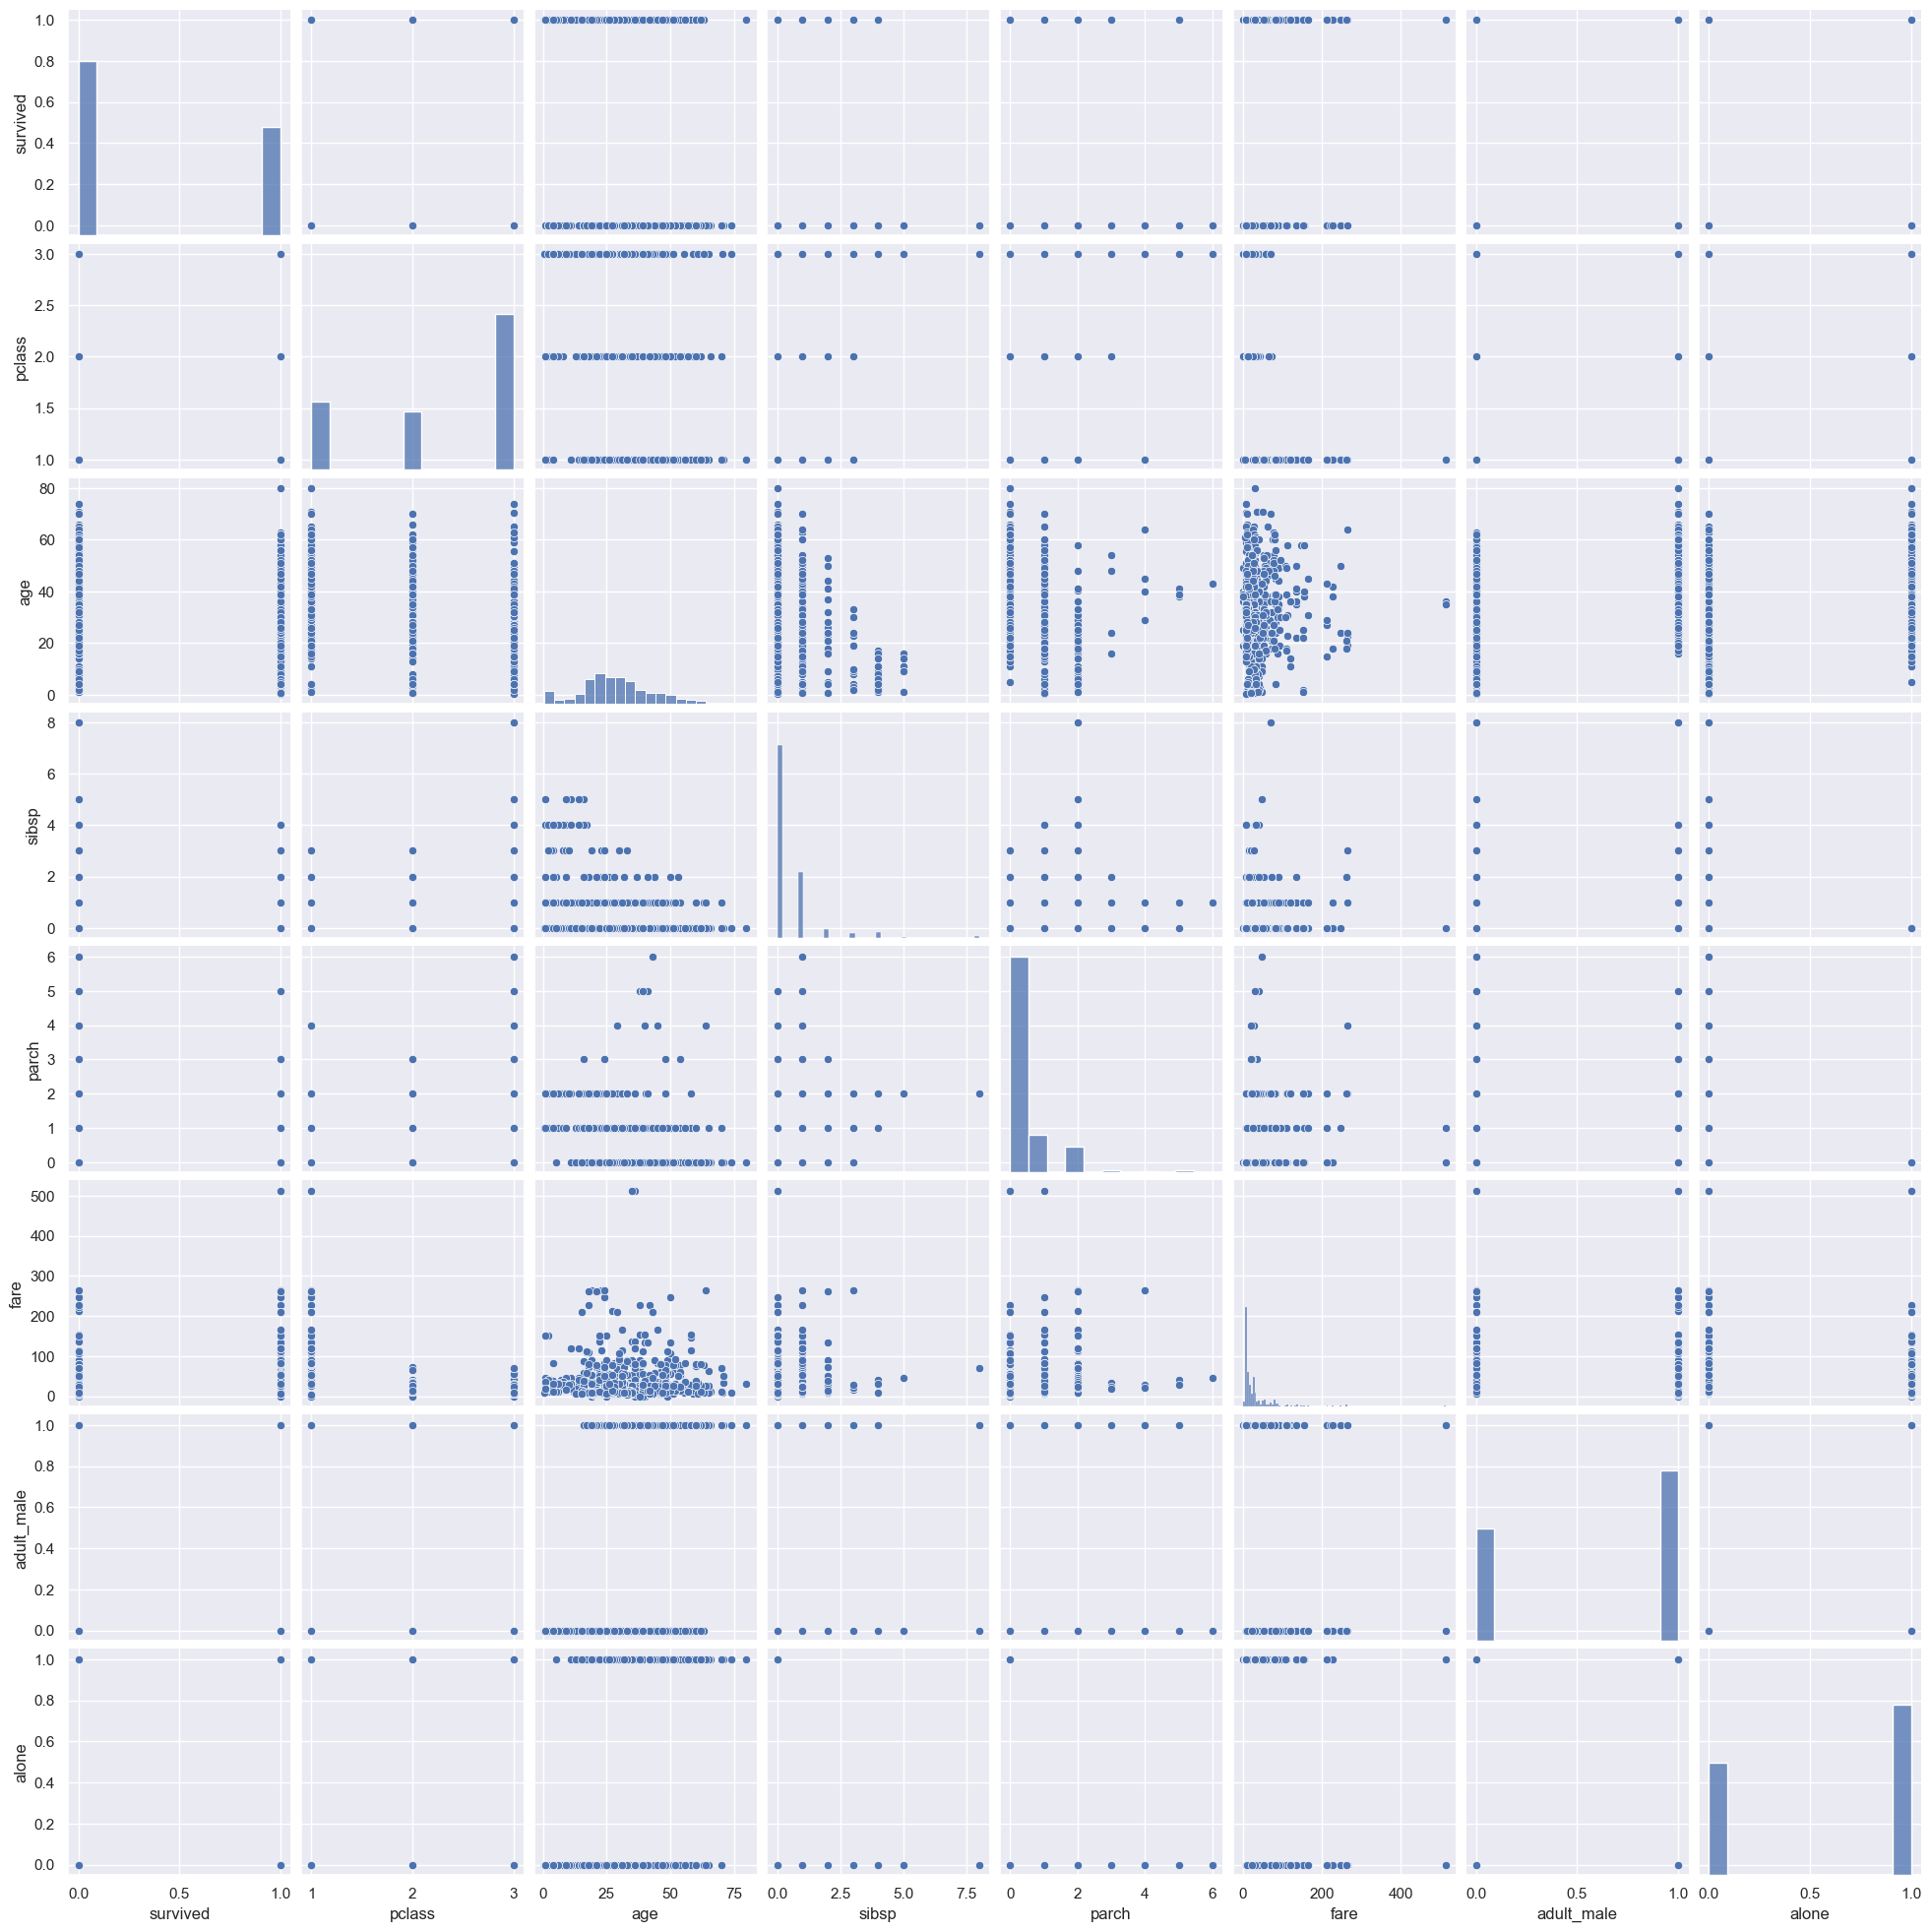

In [48]:
sns.pairplot(df2[corr2.columns])
plt.show()

In [49]:
# 대륙별 비율 파이차트로 구해보자!
df.columns

Index(['country', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')

In [50]:
df['continent']

0      AS
1      EU
2      AF
3      EU
4      AF
       ..
188    SA
189    AS
190    AS
191    AF
192    AF
Name: continent, Length: 193, dtype: object

In [69]:
continent_count = df['continent'].value_counts()
continent_count

continent
AF    53
EU    45
AS    44
OC    16
SA    12
Name: count, dtype: int64

In [52]:
type(continent_count) # index + values
# Series는 항목명 + 인덱스 + 값목록
# pie에 넣을 값은 값목록, pie에 넣을 항목명(labels)은  인덱스임.

pandas.core.series.Series

In [70]:
index = continent_count.index
index

Index(['AF', 'EU', 'AS', 'OC', 'SA'], dtype='object', name='continent')

In [71]:
values = continent_count.values
values

array([53, 45, 44, 16, 12])

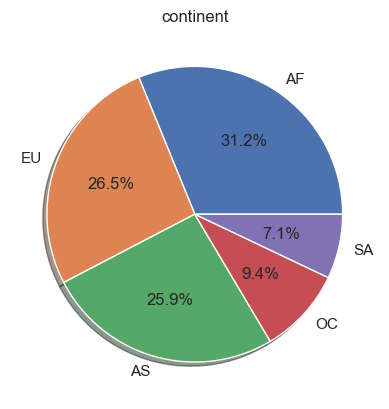

In [55]:
plt.pie(values, labels=index, autopct='%.1f%%', shadow=True)
plt.title('continent')
plt.show()

In [63]:
df.info() # 각 항목의 데이터 이름과 타입, not null 개수

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    object 
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
 5   continent                     170 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.2+ KB


In [56]:
df[df['continent']=='US']

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent


In [57]:
print(df.isnull().sum()) # isnull()이 true인 경우만 sum / count()는 True든 False든 다 셈.
print(df.dtypes)

country                          0
beer_servings                    0
spirit_servings                  0
wine_servings                    0
total_litres_of_pure_alcohol     0
continent                       23
dtype: int64
country                          object
beer_servings                     int64
spirit_servings                   int64
wine_servings                     int64
total_litres_of_pure_alcohol    float64
continent                        object
dtype: object


In [58]:
print(df.isna().sum())

country                          0
beer_servings                    0
spirit_servings                  0
wine_servings                    0
total_litres_of_pure_alcohol     0
continent                       23
dtype: int64


In [59]:
print(df['continent'].isnull().sum())

23


In [60]:
df['continent']

0      AS
1      EU
2      AF
3      EU
4      AF
       ..
188    SA
189    AS
190    AS
191    AF
192    AF
Name: continent, Length: 193, dtype: object

In [61]:
df['continent'].unique()

array(['AS', 'EU', 'AF', nan, 'SA', 'OC'], dtype=object)

In [62]:
df['continent'].value_counts()

continent
AF    53
EU    45
AS    44
OC    16
SA    12
Name: count, dtype: int64

In [72]:
df['continent'] = df['continent'].fillna('OT')
df['continent'].isnull().sum()

np.int64(0)

In [73]:
continent_count2 = df['continent'].value_counts()
continent_count2

continent
AF    53
EU    45
AS    44
OT    23
OC    16
SA    12
Name: count, dtype: int64

In [77]:
index2 = continent_count2.index
print('index', index)
values2 = continent_count2.values
print('values', values)

index Index(['AF', 'EU', 'AS', 'OT', 'OC', 'SA'], dtype='object', name='continent')
values [53 45 44 23 16 12]


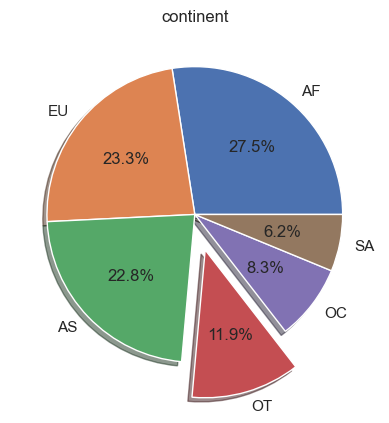

In [78]:
explode = (0, 0, 0, 0.25, 0, 0)
plt.pie(values2, 
        labels=index2, 
        explode = explode,
        autopct='%.1f%%', 
        shadow=True)
plt.title('continent')
plt.show()

In [82]:
# 대한민국의 맥주 소비량
# df[조건][컬럼][행]
df[df['country'] == 'South Korea']
# 조건을 만족하는 모든 컬럼과 행이 다 출력

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
138,South Korea,140,16,9,9.8,AS


In [83]:
df[df['country'] == 'South Korea']['beer_servings']

138    140
Name: beer_servings, dtype: int64

In [84]:
df[df['country'] == 'South Korea'][['beer_servings', 'wine_servings']]

,beer_servings,wine_servings
138,140,9


In [88]:
# 러시아의 spirit 소비량(원하는 나라의 각 술 종류별로 검색)
df[df['country'] == 'Russian Federation']['spirit_servings']

141    326
Name: spirit_servings, dtype: int64

In [86]:
df[df['country'] == 'Germany']['beer_servings']

65    346
Name: beer_servings, dtype: int64

In [91]:
# 대륙별 맥주 소비량
# df.groupby(묶을컬럼)[컬럼명]
df.groupby('continent')['beer_servings'].sum()

continent
AF    3258
AS    1630
EU    8720
OC    1435
OT    3345
SA    2101
Name: beer_servings, dtype: int64

In [92]:
df.groupby('continent')['beer_servings'].max()

continent
AF    376
AS    247
EU    361
OC    306
OT    285
SA    333
Name: beer_servings, dtype: int64

In [93]:
df.groupby('continent')['beer_servings'].mean()

continent
AF     61.471698
AS     37.045455
EU    193.777778
OC     89.687500
OT    145.434783
SA    175.083333
Name: beer_servings, dtype: float64

In [94]:
df.groupby('continent')['beer_servings'].min()

continent
AF     0
AS     0
EU     0
OC     0
OT     1
SA    93
Name: beer_servings, dtype: int64

In [95]:
df.groupby('continent')['beer_servings'].agg(['sum', 'mean', 'max'])
# agg(['sum', 'mean', 'max']) ==> 함수명으로 모아서 한꺼번에 알고싶을 때

,sum,mean,max
continent,,,
AF,3258,61.471698,376
AS,1630,37.045455,247
EU,8720,193.777778,361
OC,1435,89.687500,306
OT,3345,145.434783,285
SA,2101,175.083333,333


In [96]:
df.groupby('continent')['wine_servings'].agg(['sum', 'mean', 'max'])

,sum,mean,max
continent,,,
AF,862,16.264151,233
AS,399,9.068182,123
EU,6400,142.222222,370
OC,570,35.625000,212
OT,564,24.521739,100
SA,749,62.416667,221


In [98]:
df.groupby('continent')['beer_servings'].mean().idxmax() # idxmin()

'EU'

In [99]:
# 전체 알콜 소비량 평균보다 많은 알코올을 섭취하는 대륙을 구해보세요.
## 전체 알코올 소비량 평균

In [104]:
total_mean = df['total_litres_of_pure_alcohol'].mean()
total_mean

np.float64(4.717098445595855)

In [106]:
con_mean = df.groupby('continent')['total_litres_of_pure_alcohol'].mean()
con_mean

continent
AF    3.007547
AS    2.170455
EU    8.617778
OC    3.381250
OT    5.995652
SA    6.308333
Name: total_litres_of_pure_alcohol, dtype: float64

In [109]:
con_mean > total_mean 
# 시리즈 > 단일값
# 시리즈 내에 있는 값들을 모두 비교해줌. --> 브로드캐스팅
# (전체 시리즈에 다 영향을 미쳐 비교함)

continent
AF    False
AS    False
EU     True
OC    False
OT     True
SA     True
Name: total_litres_of_pure_alcohol, dtype: bool

In [111]:
con_mean[con_mean > total_mean]

continent
EU    8.617778
OT    5.995652
SA    6.308333
Name: total_litres_of_pure_alcohol, dtype: float64

In [112]:
# 맥주의 평균값을 구해보고,
# 대륙별 맥주 평균값을 구해보자.!

# 맥주의 평균값보다 높은 대륙 리스트를 구해보세요.
# 맥주의 최대값을 가지는 대륙은 어디인가요?

In [115]:
total_mean2 = df['beer_servings'].mean()
total_mean2

np.float64(106.16062176165804)

In [117]:
con_mean2 = df.groupby('continent')['beer_servings'].mean()
con_mean2

continent
AF     61.471698
AS     37.045455
EU    193.777778
OC     89.687500
OT    145.434783
SA    175.083333
Name: beer_servings, dtype: float64

In [118]:
con_mean2 > total_mean2

continent
AF    False
AS    False
EU     True
OC    False
OT     True
SA     True
Name: beer_servings, dtype: bool

In [119]:
con_mean2[con_mean2 > total_mean2]

continent
EU    193.777778
OT    145.434783
SA    175.083333
Name: beer_servings, dtype: float64

In [124]:
con_max2 = df.groupby('continent')['beer_servings'].max()
con_max2

continent
AF    376
AS    247
EU    361
OC    306
OT    285
SA    333
Name: beer_servings, dtype: int64

In [128]:
con_max2.max()

376